In [12]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [13]:
#Load and Explore Data

df = pd.read_csv("Customer_support_data.csv")

df.head()


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


In [14]:
df.shape


(85907, 20)

In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

In [16]:
df.describe()


,Item_price,connected_handling_time,CSAT Score
count,17206.000000,242.000000,85907.000000
mean,5660.774846,462.400826,4.242157
std,12825.728411,246.295037,1.378903
min,0.000000,0.000000,1.000000
25%,392.000000,293.000000,4.000000
50%,979.000000,427.000000,5.000000
75%,2699.750000,592.250000,5.000000
max,164999.000000,1986.000000,5.000000


In [17]:
df.duplicated().sum()


0

In [18]:
df.isna().sum()

Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64

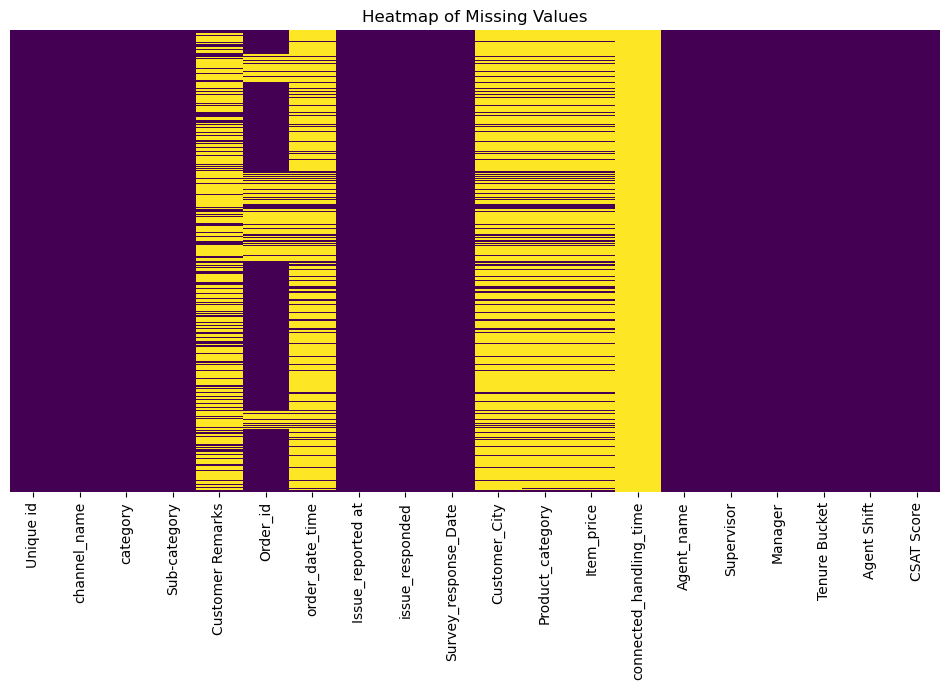

In [19]:
# Visualizing Missing Values
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Heatmap of Missing Values")
plt.show()

In [20]:
# Fill Missing CSAT Score
df['CSAT Score'] = df['CSAT Score'].fillna(df['CSAT Score'].median())

In [21]:
# Handle Outliers (IQR method)
Q1 = df['connected_handling_time'].quantile(0.25)
Q3 = df['connected_handling_time'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['connected_handling_time'] < (Q1 - 1.5 * IQR)) | (df['connected_handling_time'] > (Q3 + 1.5 * IQR)))]


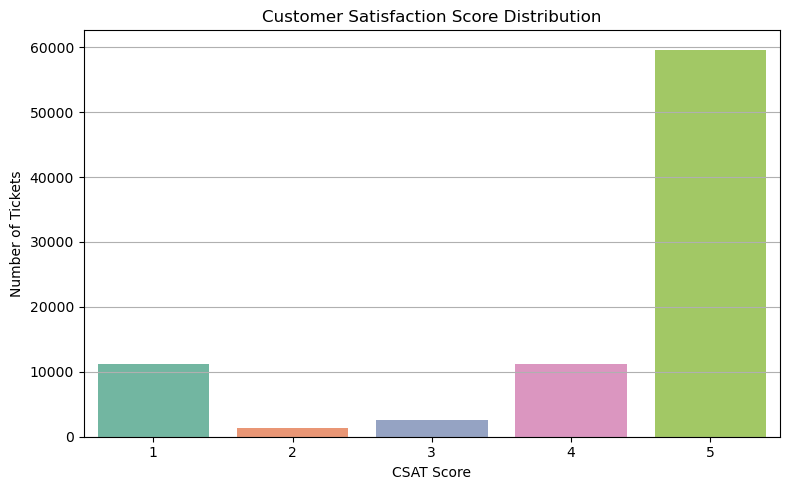

In [22]:
# 5Exploratory Data Analysis (EDA)

# CSAT Score Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='CSAT Score', data=df, hue='CSAT Score', palette='Set2', legend=False)
plt.title('Customer Satisfaction Score Distribution')
plt.xlabel('CSAT Score')
plt.ylabel('Number of Tickets')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

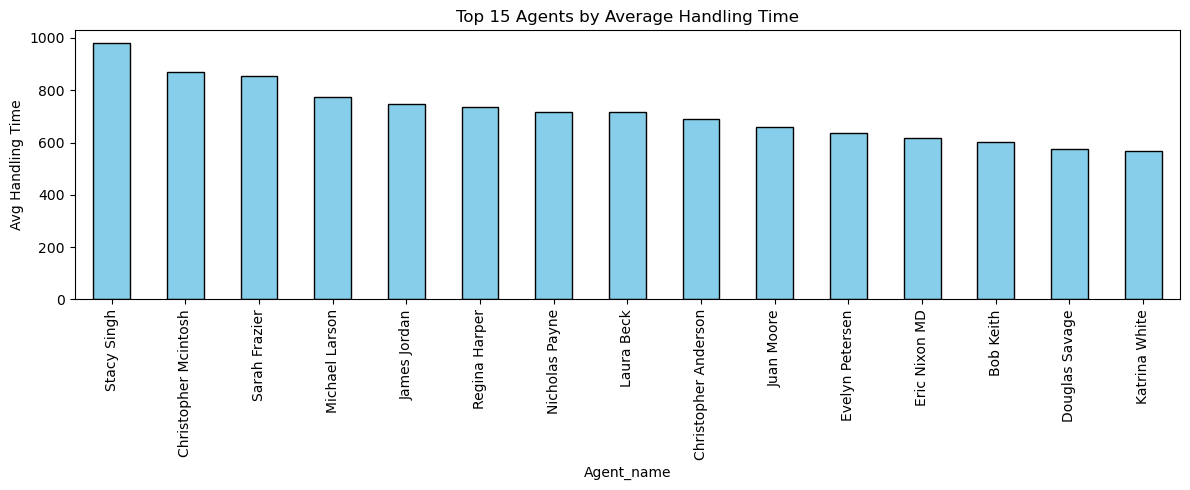

In [23]:
# Avg Handling Time by Agent
plt.figure(figsize=(12, 5))
avg_handling = df.groupby('Agent_name')['connected_handling_time'].mean().sort_values(ascending=False).head(15)
avg_handling.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Top 15 Agents by Average Handling Time')
plt.ylabel('Avg Handling Time')
plt.tight_layout()
plt.show()


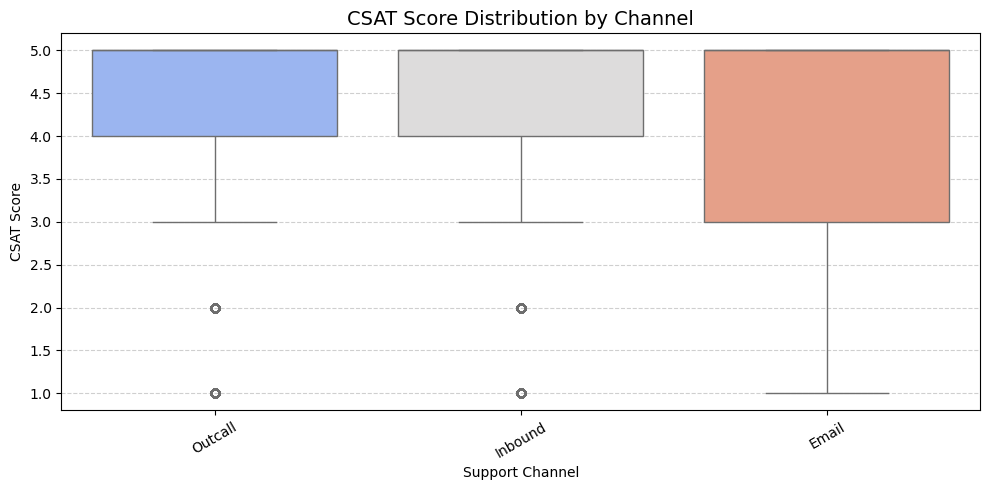

In [24]:
# CSAT by Support Channel
plt.figure(figsize=(10, 5))
sns.boxplot(x='channel_name', y='CSAT Score', hue='channel_name', data=df, palette='coolwarm', legend=False)
plt.title('CSAT Score Distribution by Channel', fontsize=14)
plt.xlabel('Support Channel')
plt.ylabel('CSAT Score')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

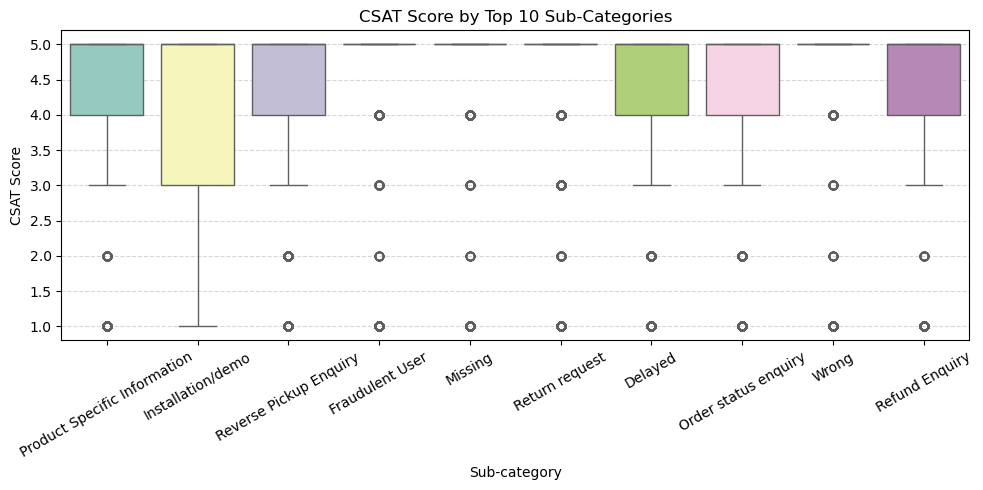

In [25]:
# Top 10 Sub-categories by CSAT
top_subcats = df['Sub-category'].value_counts().head(10).index
plt.figure(figsize=(10, 5))
sns.boxplot(
    x='Sub-category', y='CSAT Score',
    hue='Sub-category', data=df[df['Sub-category'].isin(top_subcats)],
    palette='Set3', legend=False
)
plt.title('CSAT Score by Top 10 Sub-Categories')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

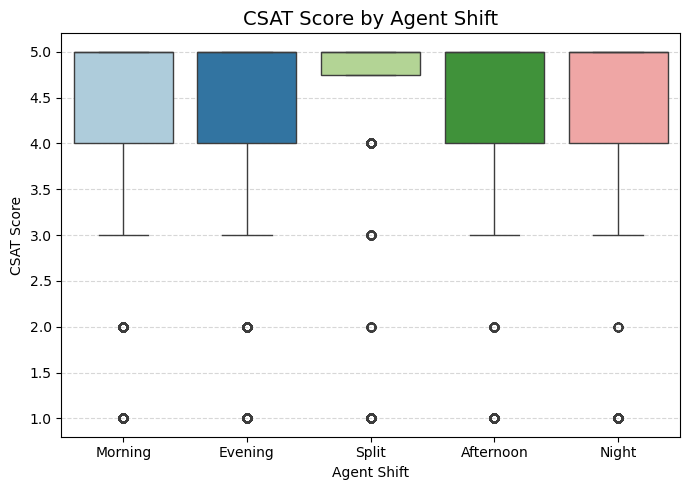

In [26]:
# CSAT by Agent Shift
plt.figure(figsize=(7, 5))
sns.boxplot(x='Agent Shift', y='CSAT Score', hue='Agent Shift', data=df, palette='Paired', legend=False)
plt.title('CSAT Score by Agent Shift', fontsize=14)
plt.xlabel('Agent Shift')
plt.ylabel('CSAT Score')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


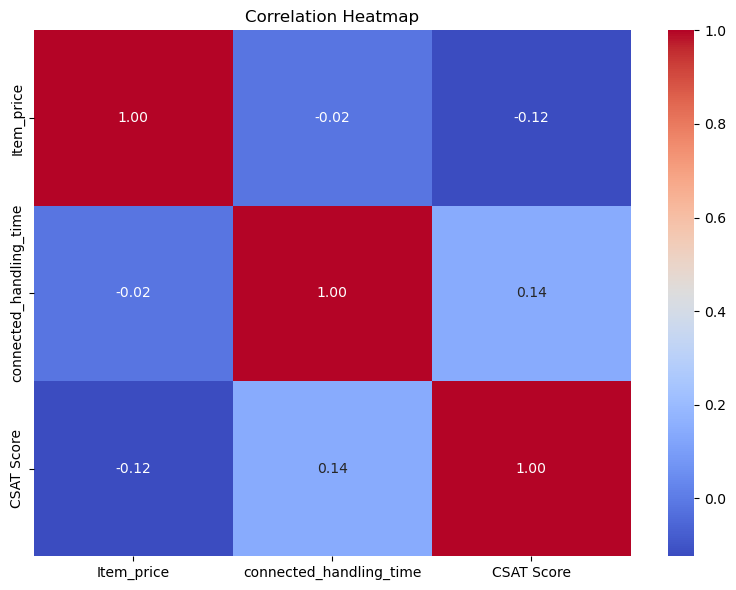

In [27]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


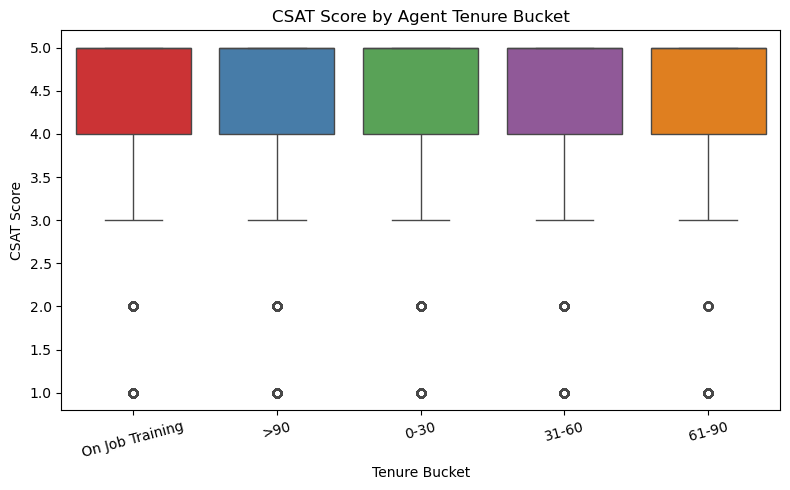

In [28]:
# CSAT by Tenure Bucket
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Tenure Bucket',
    y='CSAT Score',
    hue='Tenure Bucket',
    data=df,
    palette='Set1',
    legend=False
)
plt.title('CSAT Score by Agent Tenure Bucket')
plt.xlabel('Tenure Bucket')
plt.ylabel('CSAT Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [29]:
# 6. Feature Engineering
def csat_level(score):
    if score <= 2:
        return 'Low'
    elif score == 3:
        return 'Medium'
    else:
        return 'High'

df['CSAT_Level'] = df['CSAT Score'].apply(csat_level)


In [30]:
# Encode categorical features
le = LabelEncoder()
for col in ['channel_name', 'category', 'Sub-category', 'Customer_City', 'Product_category', 'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift']:
    df[col] = le.fit_transform(df[col].astype(str))


In [31]:
# Drop redundant columns
df.drop(['CSAT Score', 'Unique id', 'Survey_response_Date', 'Order_id', 'order_date_time', 'issue_responded'], axis=1, inplace=True)


In [32]:
# 7. Preprocessing
X = df.drop('CSAT_Level', axis=1)
y = df['CSAT_Level']

le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))

X = X.fillna(X.median(numeric_only=True))
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)


In [33]:
# 8. Model Building and Evaluation

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression Report:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

Logistic Regression Report:
              precision    recall  f1-score   support

        High       0.83      1.00      0.90     14167
         Low       0.50      0.01      0.01      2502
      Medium       0.00      0.00      0.00       512

    accuracy                           0.82     17181
   macro avg       0.44      0.34      0.31     17181
weighted avg       0.75      0.82      0.75     17181



In [34]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Random Forest Report:
              precision    recall  f1-score   support

        High       0.83      0.98      0.90     14167
         Low       0.34      0.05      0.09      2502
      Medium       0.00      0.00      0.00       512

    accuracy                           0.82     17181
   macro avg       0.39      0.34      0.33     17181
weighted avg       0.73      0.82      0.75     17181



In [35]:
# Hyperparameter Tuning
param_grid = {'n_estimators': [50, 100], 'max_depth': [5, 10]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 100}
Best Score: 0.826513386316047


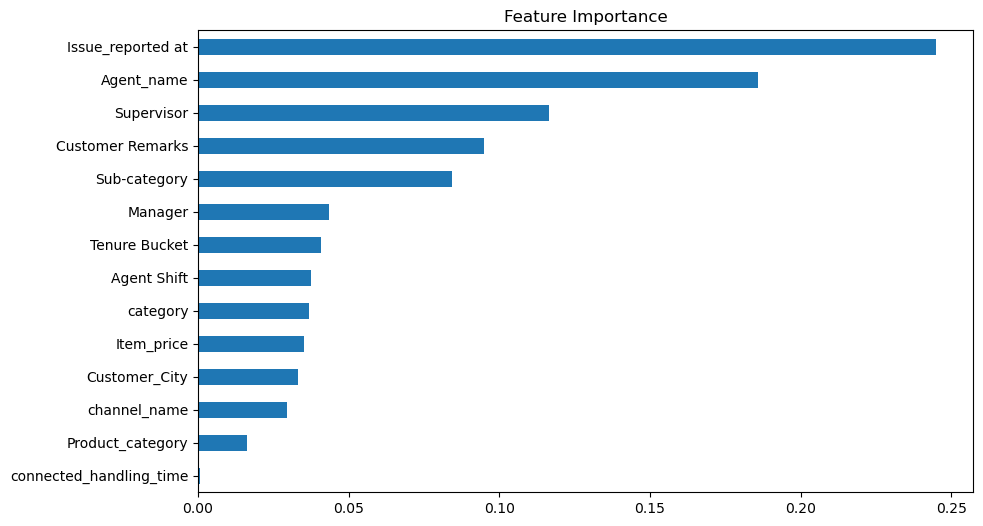

In [36]:
#  Feature Importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance')
plt.show()

In [37]:
 #Additional Models

# Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Report:
              precision    recall  f1-score   support

        High       0.85      0.84      0.84     14167
         Low       0.29      0.31      0.30      2502
      Medium       0.02      0.03      0.03       512

    accuracy                           0.73     17181
   macro avg       0.39      0.39      0.39     17181
weighted avg       0.75      0.73      0.74     17181



In [38]:
# K-Nearest Neighbors
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Classifier Report:")
print(classification_report(y_test, y_pred_knn, zero_division=0))

KNN Classifier Report:
              precision    recall  f1-score   support

        High       0.83      0.97      0.89     14167
         Low       0.26      0.06      0.10      2502
      Medium       0.00      0.00      0.00       512

    accuracy                           0.81     17181
   macro avg       0.36      0.34      0.33     17181
weighted avg       0.72      0.81      0.75     17181



In [39]:
# XGBoost
from xgboost import XGBClassifier
le_y = LabelEncoder()
y_train_enc = le_y.fit_transform(y_train)
y_test_enc = le_y.transform(y_test)

xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb.fit(X_train, y_train_enc)
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb_labels = le_y.inverse_transform(y_pred_xgb)

print("XGBoost Classifier Report:")
print(classification_report(y_test, y_pred_xgb_labels, zero_division=0))

XGBoost Classifier Report:
              precision    recall  f1-score   support

        High       0.84      0.98      0.91     14167
         Low       0.59      0.16      0.25      2502
      Medium       0.00      0.00      0.00       512

    accuracy                           0.83     17181
   macro avg       0.48      0.38      0.39     17181
weighted avg       0.78      0.83      0.78     17181

